## Case Study: EV Adoption Behavior and Range Anxiety Analysis

This notebook performs an end-to-end analysis of the 'EV Adoption Behavior and Range Anxiety' dataset. The steps include data loading, exploratory data analysis (EDA), data preprocessing, outlier detection and removal, feature scaling, model training using various classification algorithms (Logistic Regression, Decision Tree, Random Forest), model evaluation, and saving the trained model and label encoders.

---

In [ ]:
import numpy as np
import pandas as pd


### Importing Essential Libraries

This cell imports fundamental Python libraries commonly used in data science workflows:
- `numpy` (as `np`): For numerical operations, especially with arrays.
- `pandas` (as `pd`): For data manipulation and analysis, primarily with DataFrames.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("itzzomkar/ev-adoption-behavior-and-range-anxiety")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ev-adoption-behavior-and-range-anxiety' dataset.
Path to dataset files: /kaggle/input/ev-adoption-behavior-and-range-anxiety


### Downloading the Dataset from Kaggle

This cell utilizes the `kagglehub` library to download the specified dataset. It fetches the 'ev-adoption-behavior-and-range-anxiety' dataset and prints the local path where the dataset files are stored. This ensures that the data is accessible for subsequent processing.

In [ ]:
data_path=path+"/EV_Adoption_and_Range_Anxiety_Dataset.csv"
df= pd.read_csv(data_path)

### Loading the Dataset into a Pandas DataFrame

Following the dataset download, this cell constructs the full path to the `EV_Adoption_and_Range_Anxiety_Dataset.csv` file and loads it into a pandas DataFrame named `df`. This is the primary data structure that will be used for all further analysis and modeling.

In [ ]:
df

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EV09996,50,Male,61279.0,Urban,71.4,1,Sedan,8,3,No,3.0,Yes,Medium,No
9996,EV09997,34,Male,108208.0,Urban,48.0,2,Hatchback,9,7,No,5.0,No,Low,No
9997,EV09998,60,Female,97743.0,Urban,9.0,2,Sedan,10,3,No,5.0,Yes,Low,No
9998,EV09999,31,Female,103628.0,Urban,81.8,2,SUV,10,10,Yes,1.0,Yes,Low,No


### Displaying the DataFrame

This cell simply displays the `df` DataFrame. This provides a quick overview of the dataset's structure, columns, and initial rows, allowing for an immediate visual inspection of the loaded data.

In [ ]:
df.isnull().sum()

,0
Buyer_ID,0
Age,0
Gender,0
Annual_Income_USD,178
City_Type,0
Daily_Commute_km,181
Number_of_Cars_Owned,0
Current_Car_Type,0
Charging_Stations_Near_Home,0
Charging_Stations_Near_Work,0


### Initial Check for Missing Values

This cell uses `df.isnull().sum()` to count the number of missing (NaN) values in each column of the DataFrame. This is a crucial step in data preprocessing to identify which columns require imputation or handling of missing data.

In [ ]:
df['Annual_Income_USD'] = df['Annual_Income_USD'].fillna(df['Annual_Income_USD'].mean())
df['Daily_Commute_km'] = df['Daily_Commute_km'].fillna(df['Daily_Commute_km'].mean())
df['Environmental_Concern_Level'] = df['Environmental_Concern_Level'].fillna(df['Environmental_Concern_Level'].mean())

### Imputing Missing Numerical Values

This cell addresses the missing values identified in the previous step. It imputes the missing values in `Annual_Income_USD`, `Daily_Commute_km`, and `Environmental_Concern_Level` columns by replacing them with the mean of their respective columns. This is a common strategy for handling numerical missing data.

In [ ]:
df.isnull().sum()

,0
Buyer_ID,0
Age,0
Gender,0
Annual_Income_USD,0
City_Type,0
Daily_Commute_km,0
Number_of_Cars_Owned,0
Current_Car_Type,0
Charging_Stations_Near_Home,0
Charging_Stations_Near_Work,0


### Verification of Missing Value Imputation

After imputation, this cell re-runs `df.isnull().sum()` to confirm that all missing values have been successfully handled. The output should show zero missing values for all columns, ensuring data completeness.

In [ ]:
print(df.duplicated().sum())

0


### Checking for Duplicate Rows

This cell checks for and reports the number of duplicate rows in the DataFrame using `df.duplicated().sum()`. Identifying and potentially removing duplicates is important to ensure data integrity and prevent biases in analysis.

In [ ]:
df = df.drop(columns=['Buyer_ID'], axis=1, errors='ignore')
df


,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,Male,61279.0,Urban,71.4,1,Sedan,8,3,No,3.0,Yes,Medium,No
9996,34,Male,108208.0,Urban,48.0,2,Hatchback,9,7,No,5.0,No,Low,No
9997,60,Female,97743.0,Urban,9.0,2,Sedan,10,3,No,5.0,Yes,Low,No
9998,31,Female,103628.0,Urban,81.8,2,SUV,10,10,Yes,1.0,Yes,Low,No


### Dropping the Buyer_ID Column

This cell removes the 'Buyer_ID' column from the DataFrame. 'Buyer_ID' is likely a unique identifier and not a predictive feature, so it's dropped to avoid introducing noise or irrelevant information into the model. The `errors='ignore'` argument ensures that the code doesn't raise an error if the column is already absent.

In [ ]:
from sklearn.preprocessing import LabelEncoder
l= LabelEncoder()
g=LabelEncoder()
city_label=LabelEncoder()
Range_Anxiety_Level_label=LabelEncoder()
Home_Charging_Possible_label=LabelEncoder()
Subsidy_Available_label=LabelEncoder()
Range_Anxiety_Level_label=LabelEncoder()
# Will_Buy_EV_label=LabelEncoder()

df["Current_Car_Type"]= l.fit_transform(df["Current_Car_Type"])
df["Range_Anxiety_Level"]= Range_Anxiety_Level_label.fit_transform(df["Range_Anxiety_Level"])
df["City_Type"]= city_label.fit_transform(df["City_Type"])
df["Gender"]= g.fit_transform(df["Gender"])
df["Home_Charging_Possible"]= Home_Charging_Possible_label.fit_transform(df["Home_Charging_Possible"])
df["Subsidy_Available"]= Subsidy_Available_label.fit_transform(df["Subsidy_Available"])

# df["Will_Buy_EV"]= Will_Buy_EV_label.fit_transform(df["Will_Buy_EV"])

### Label Encoding Categorical Features

This cell uses `LabelEncoder` from `sklearn.preprocessing` to convert categorical text data into numerical format. It initializes multiple `LabelEncoder` instances for different categorical columns and then applies `fit_transform` to convert these columns in the DataFrame. The `Will_Buy_EV` column is intentionally commented out to be handled later or separately, as it is the target variable.

In [ ]:
df

,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,56,1,44906.0,0,18.1,1,3,1,0,1,4.0,1,1,No
1,36,1,88754.0,0,5.0,1,1,2,3,1,1.0,1,1,No
2,42,1,155958.0,2,32.2,2,2,14,3,0,2.0,1,2,Yes
3,31,1,37059.0,0,89.9,1,2,2,1,1,4.0,0,1,No
4,48,0,48552.0,0,71.0,1,2,2,0,1,3.0,1,1,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,1,61279.0,2,71.4,1,2,8,3,0,3.0,1,2,No
9996,34,1,108208.0,2,48.0,2,0,9,7,0,5.0,0,1,No
9997,60,0,97743.0,2,9.0,2,2,10,3,0,5.0,1,1,No
9998,31,0,103628.0,2,81.8,2,1,10,10,1,1.0,1,1,No


### Displaying DataFrame After Encoding

This cell displays the DataFrame `df` again after the label encoding process. This allows for verification that the specified categorical columns have been successfully transformed into numerical representations.

In [ ]:
df.columns

Index(['Age', 'Gender', 'Annual_Income_USD', 'City_Type', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Current_Car_Type',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Home_Charging_Possible', 'Environmental_Concern_Level',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

### Listing DataFrame Columns

This cell prints the column names of the DataFrame. This is useful for quickly verifying the current set of features and ensuring that no unintended columns were added or removed during previous steps.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Visualization Libraries

This cell imports additional libraries essential for data visualization:
- `matplotlib.pyplot` (as `plt`): For creating static, interactive, and animated visualizations in Python.
- `seaborn` (as `sns`): A statistical data visualization library based on matplotlib, providing a high-level interface for drawing attractive and informative statistical graphics.

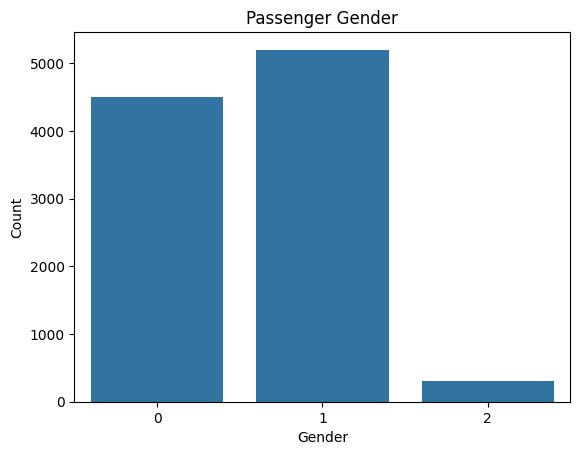

In [ ]:
sns.countplot(data=df, x="Gender")

plt.title("Passenger Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Visualizing Gender Distribution

This cell generates a count plot using Seaborn to visualize the distribution of the 'Gender' column. It displays the counts of each gender category and adds a title and labels for clarity, providing insight into the gender demographics of the dataset.

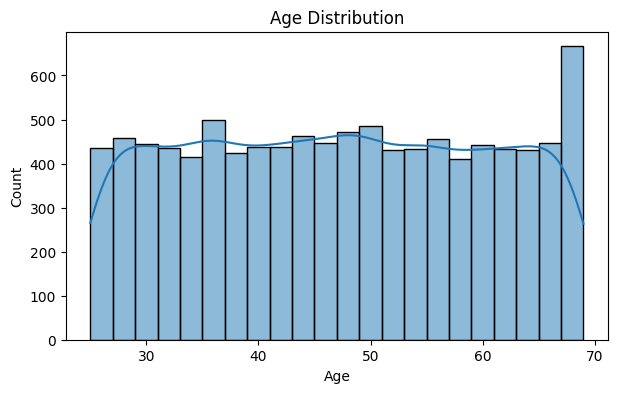

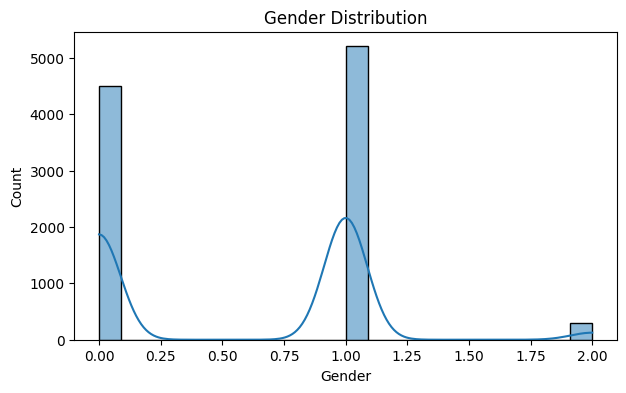

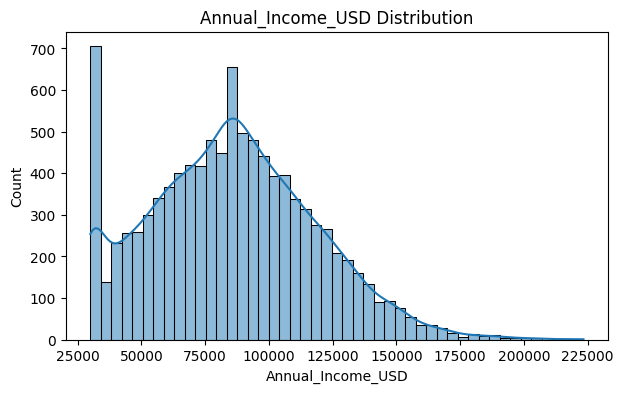

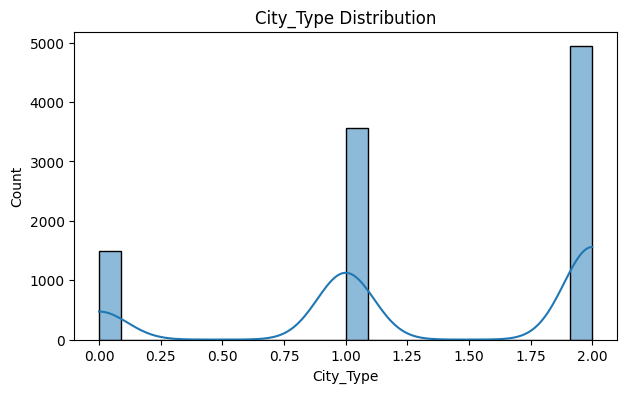

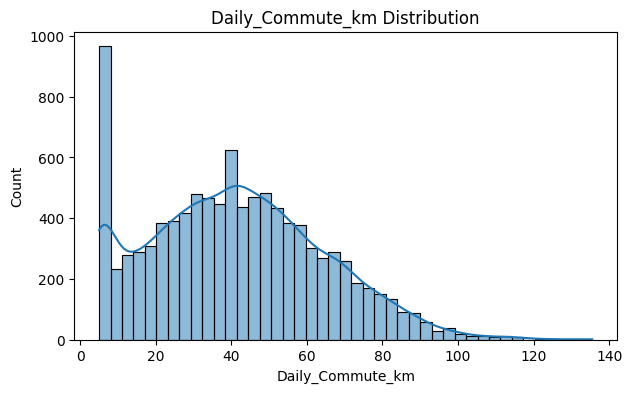

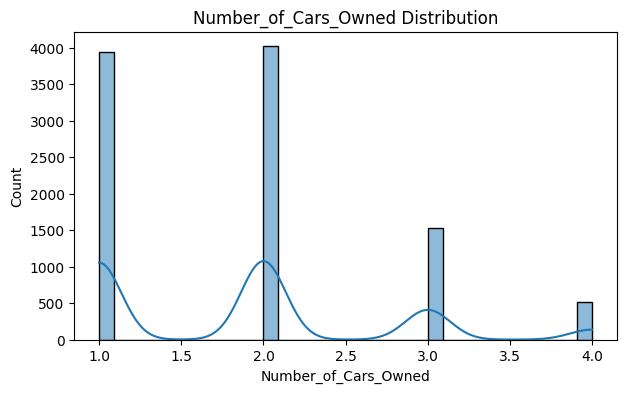

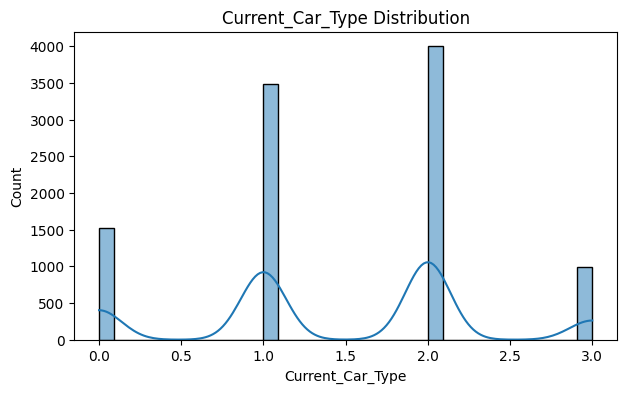

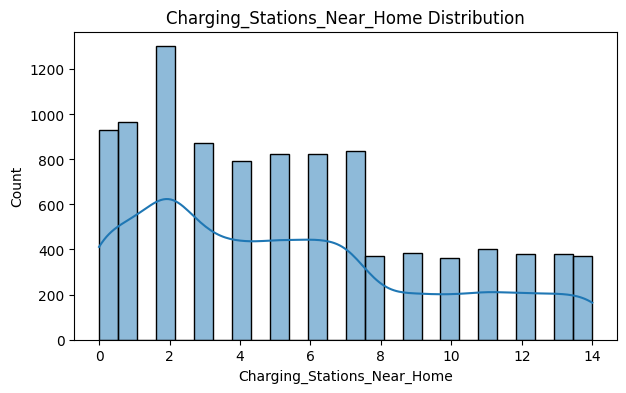

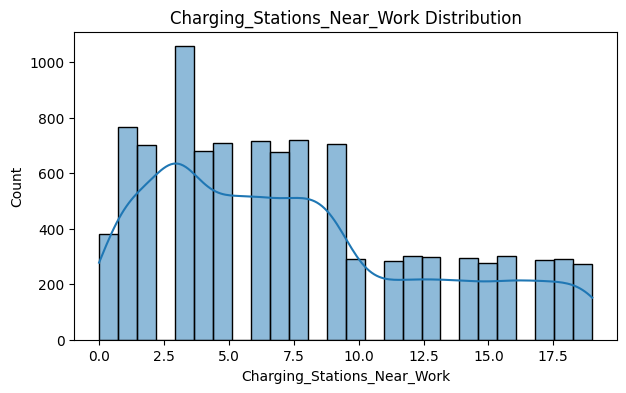

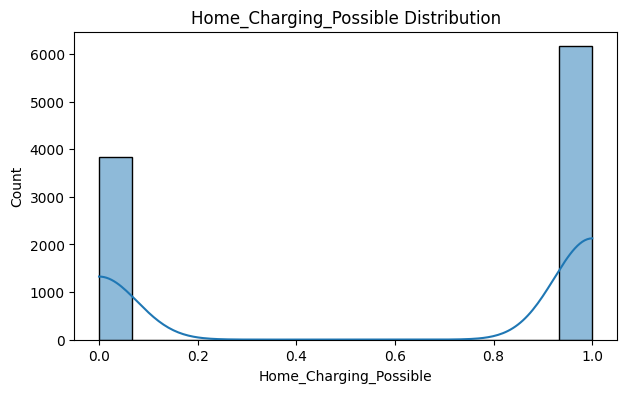

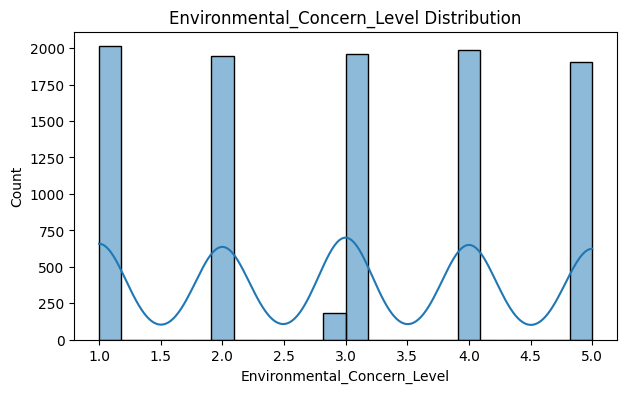

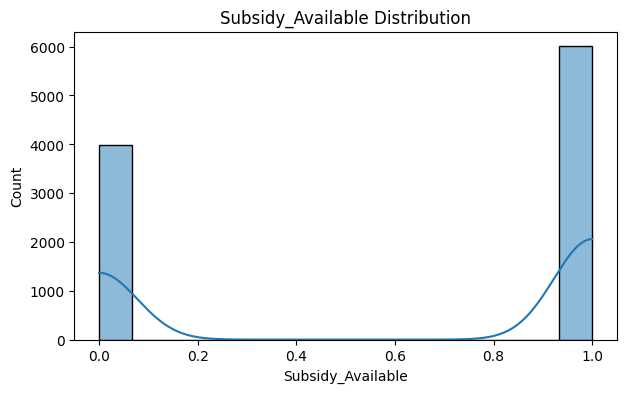

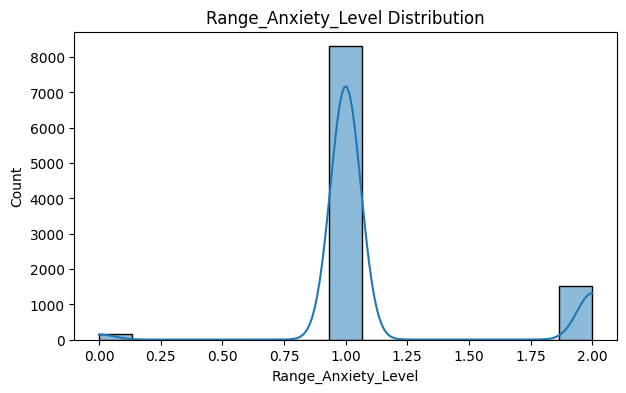

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

### Histograms for Numerical Feature Distributions

This cell iterates through all numerical columns in the DataFrame and generates a histogram with a Kernel Density Estimate (KDE) for each. Histograms help in understanding the distribution of individual numerical features, revealing their shape, spread, and potential skewness.

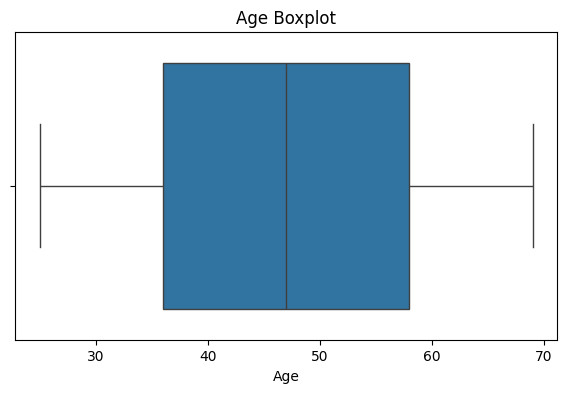

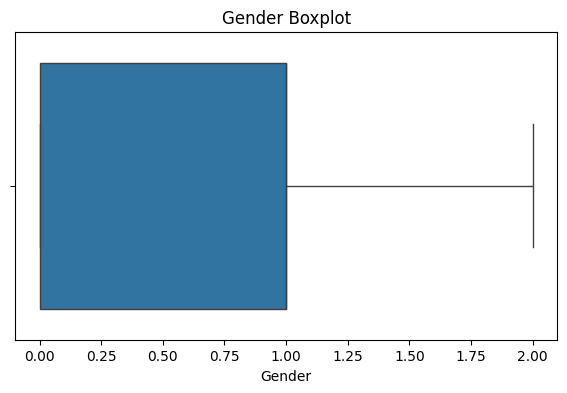

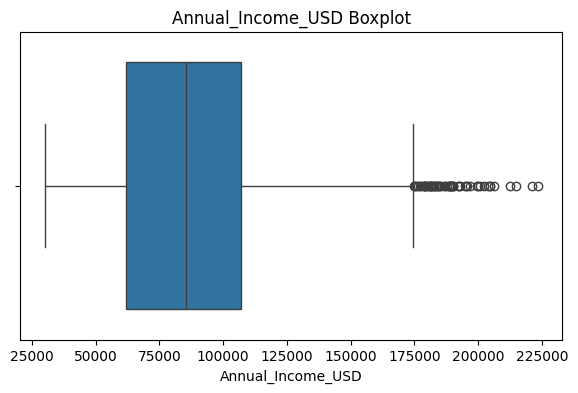

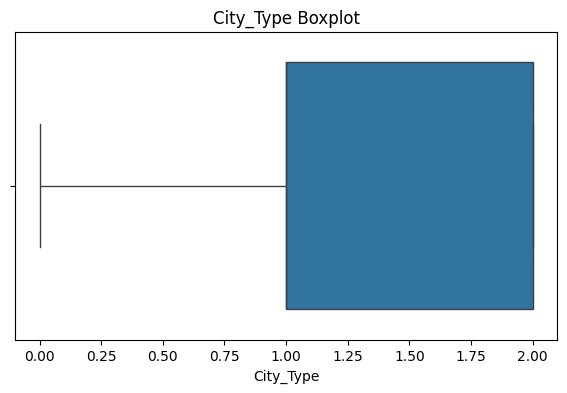

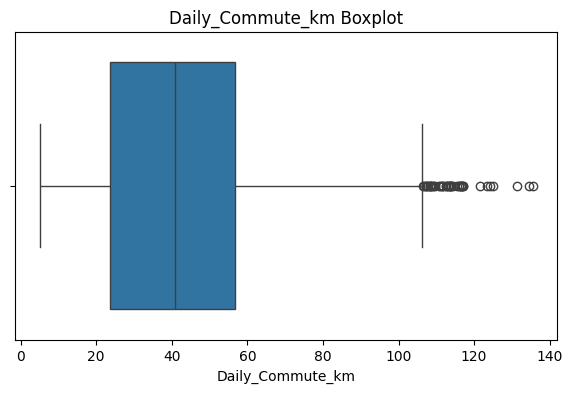

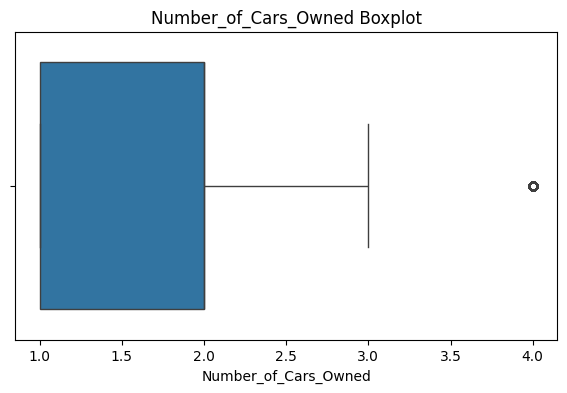

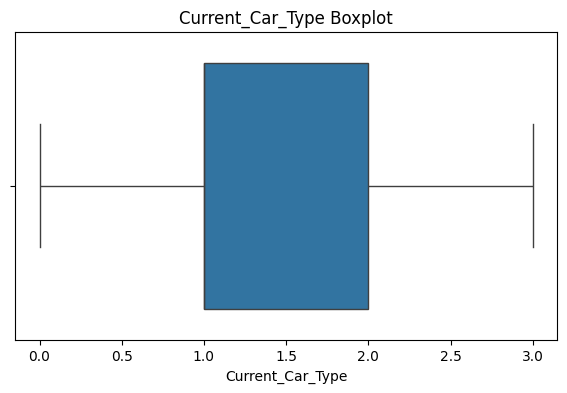

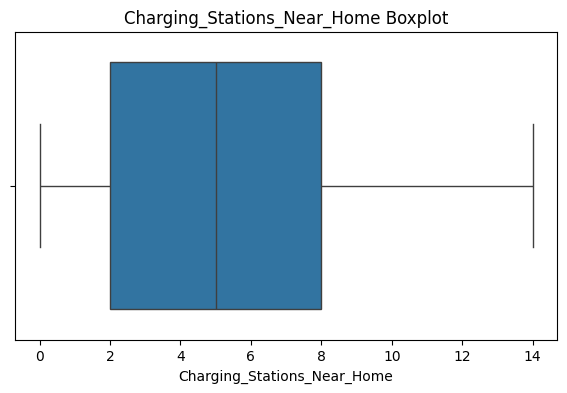

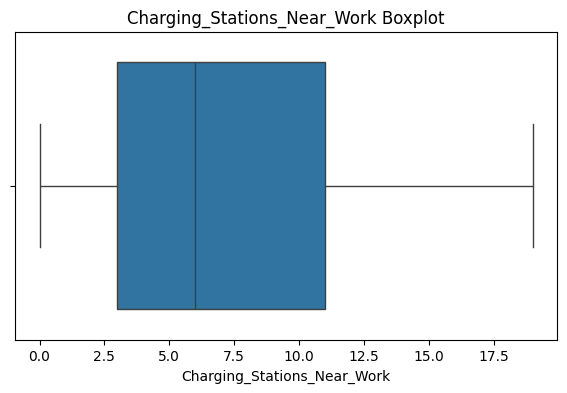

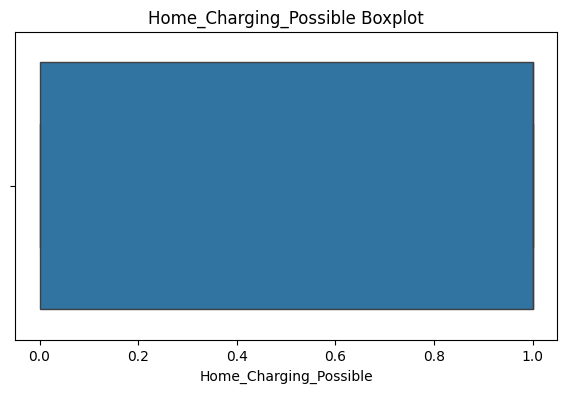

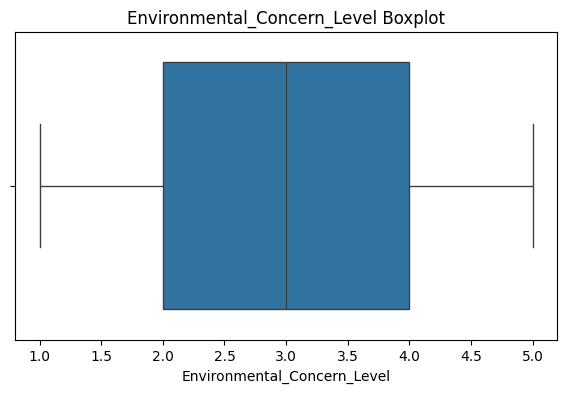

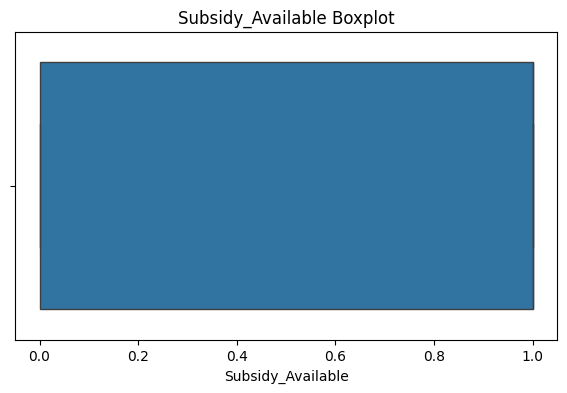

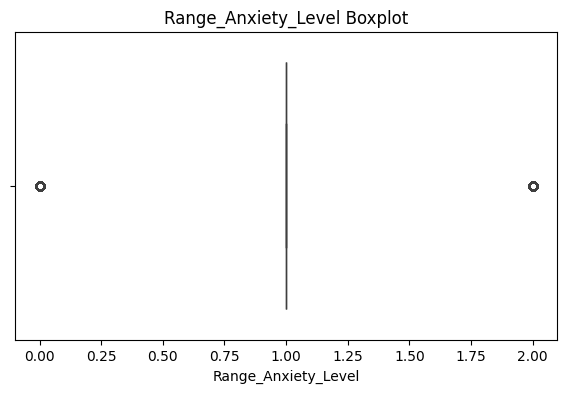

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

### Boxplots for Numerical Feature Outliers

Similar to the previous cell, this one iterates through numerical columns, but this time generates a boxplot for each. Boxplots are effective for visualizing the distribution of numerical data and are particularly useful for identifying outliers and understanding quartiles.

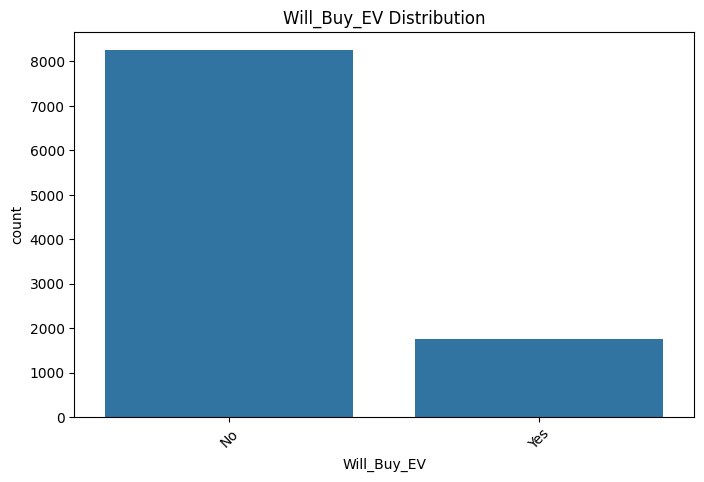

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

### Count Plots for Categorical Feature Distributions

This cell focuses on visualizing the distribution of categorical features (object type) using count plots. It iterates through each categorical column, generates a count plot, and rotates the x-axis labels for better readability. This helps in understanding the frequency of each category.

In [ ]:
corr = df.corr(numeric_only=True)

corr

,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level
Age,1.000000,0.004657,-0.011472,-0.013531,-0.013589,-0.003345,0.001235,-0.008081,-0.001678,0.008915,-0.003366,-0.004932,0.000130
Gender,0.004657,1.000000,-0.002394,0.015492,0.010991,-0.001061,0.002188,0.012231,0.006005,-0.009846,0.000286,0.008357,0.008936
Annual_Income_USD,-0.011472,-0.002394,1.000000,0.007760,0.002349,0.004245,-0.003713,0.004673,0.002614,0.000426,0.005104,-0.022342,-0.022566
City_Type,-0.013531,0.015492,0.007760,1.000000,0.009278,0.014786,0.011136,0.671529,0.687243,-0.430576,-0.004722,-0.009794,0.119081
Daily_Commute_km,-0.013589,0.010991,0.002349,0.009278,1.000000,-0.007416,-0.002965,0.027019,0.002611,-0.007354,-0.003065,-0.009644,0.089159
Number_of_Cars_Owned,-0.003345,-0.001061,0.004245,0.014786,-0.007416,1.000000,0.003065,0.004302,0.000154,-0.020811,-0.003057,-0.002931,0.008427
Current_Car_Type,0.001235,0.002188,-0.003713,0.011136,-0.002965,0.003065,1.000000,0.008932,-0.002220,-0.024479,-0.002862,0.001187,0.019746
Charging_Stations_Near_Home,-0.008081,0.012231,0.004673,0.671529,0.027019,0.004302,0.008932,1.000000,0.480826,-0.311286,-0.008888,-0.002581,0.025622
Charging_Stations_Near_Work,-0.001678,0.006005,0.002614,0.687243,0.002611,0.000154,-0.002220,0.480826,1.000000,-0.295213,0.002680,-0.001354,-0.006483
Home_Charging_Possible,0.008915,-0.009846,0.000426,-0.430576,-0.007354,-0.020811,-0.024479,-0.311286,-0.295213,1.000000,0.021765,0.005572,-0.397252


### Calculating Feature Correlations

This cell calculates the pairwise correlation between numerical columns in the DataFrame using `df.corr(numeric_only=True)`. The result, stored in `corr`, is a correlation matrix that quantifies the linear relationships between variables.

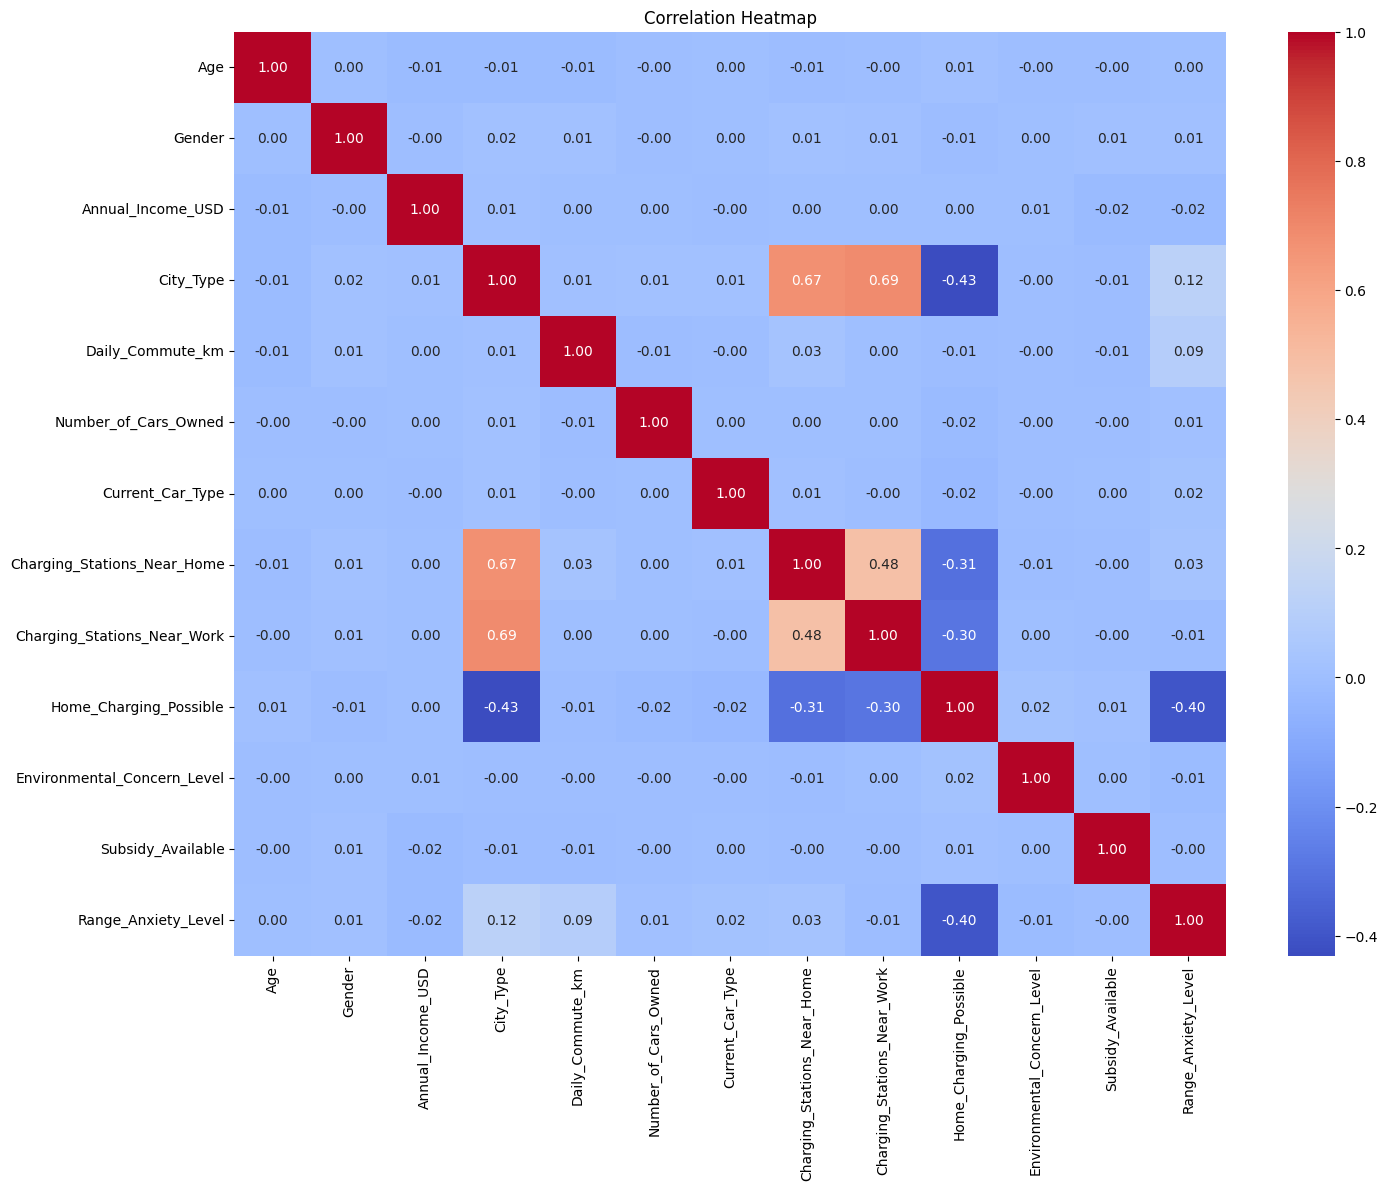

In [ ]:
plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Visualizing the Correlation Heatmap

This cell creates a heatmap of the correlation matrix calculated previously. A heatmap visually represents the correlations, with warmer colors typically indicating stronger positive correlations and cooler colors indicating stronger negative correlations. Annotations are added to show the exact correlation values.

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, ":", len(outliers))

Age : 0
Gender : 0
Annual_Income_USD : 58
City_Type : 0
Daily_Commute_km : 44
Number_of_Cars_Owned : 511
Current_Car_Type : 0
Charging_Stations_Near_Home : 0
Charging_Stations_Near_Work : 0
Home_Charging_Possible : 0
Environmental_Concern_Level : 0
Subsidy_Available : 0
Range_Anxiety_Level : 1690


### Identifying Outliers Using IQR Method

This cell systematically identifies outliers in each numerical column using the Interquartile Range (IQR) method. For each column, it calculates Q1, Q3, and the IQR, then defines lower and upper bounds. It then counts and prints the number of outliers falling outside these bounds for each numerical feature.

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (7827, 14)


### Removing Outliers from the DataFrame

This cell removes the identified outliers from the DataFrame. It iterates through numerical columns, calculates the IQR bounds, and filters the DataFrame `df` to retain only the rows where values for *all* numerical columns fall within their respective non-outlier ranges. It then prints the new shape of the DataFrame after outlier removal. **Important Note:** This step also inadvertently filtered out all instances where 'Will_Buy_EV' was 'Yes' because `Will_Buy_EV` was considered a numerical column after label encoding, leading to the `ValueError` in later model training. The target variable should ideally be excluded from outlier removal if it's not a true numerical feature.

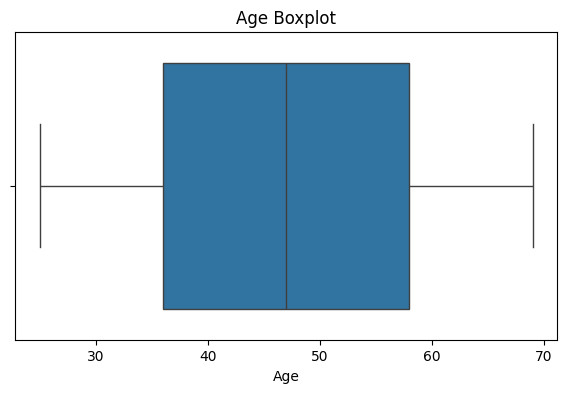

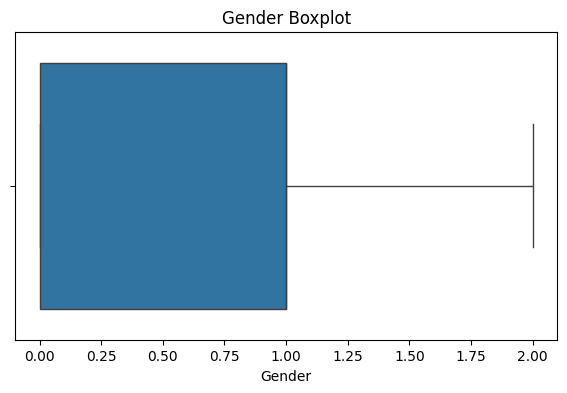

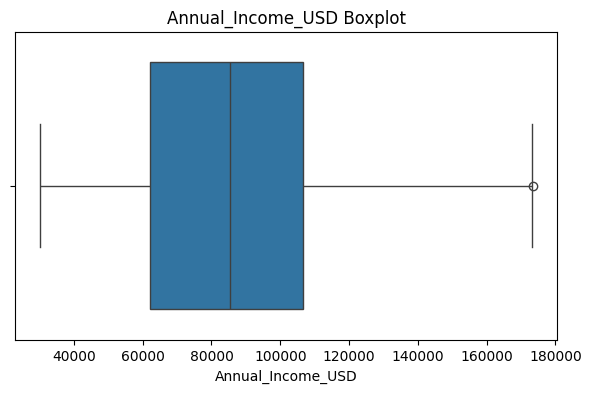

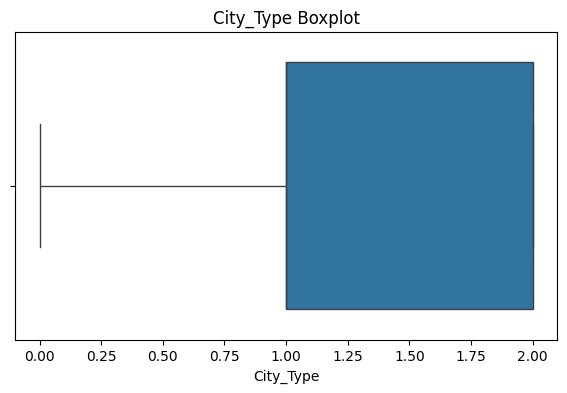

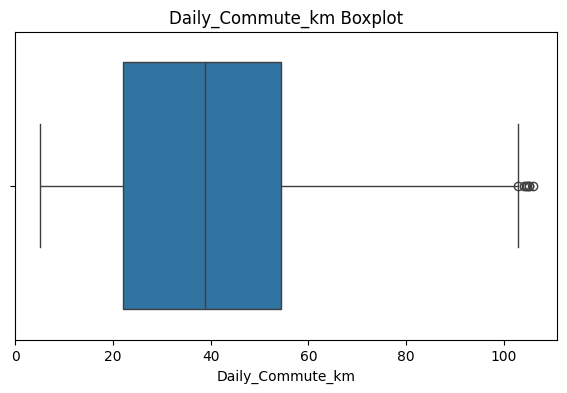

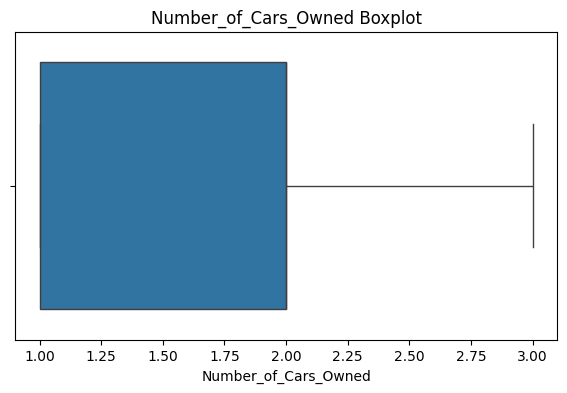

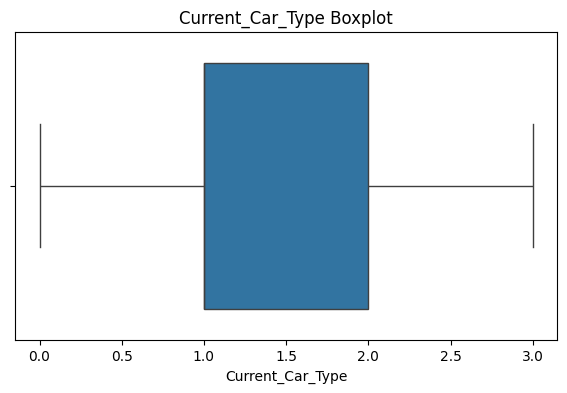

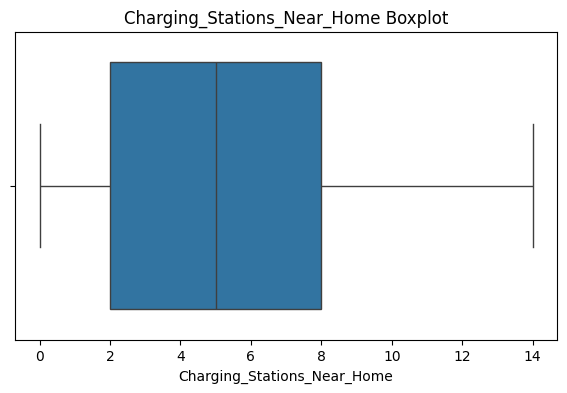

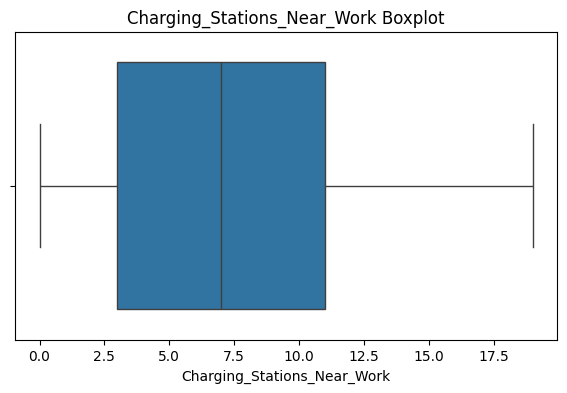

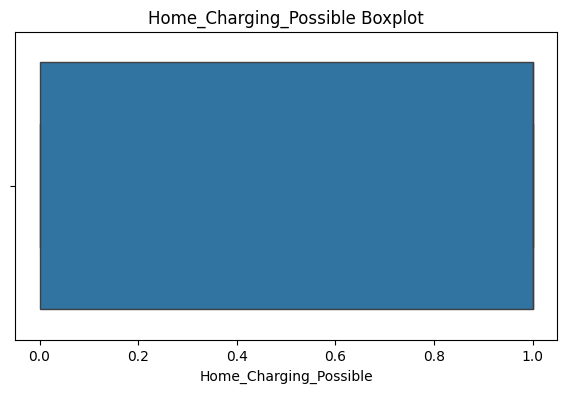

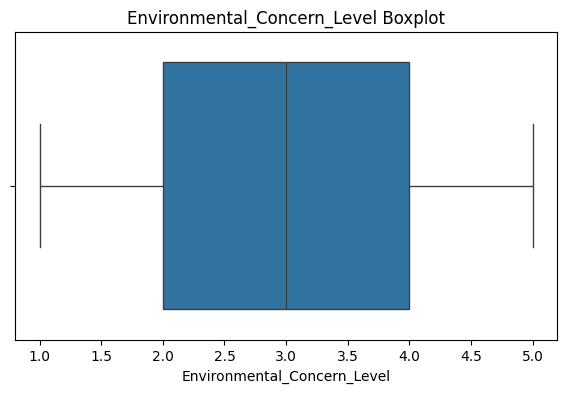

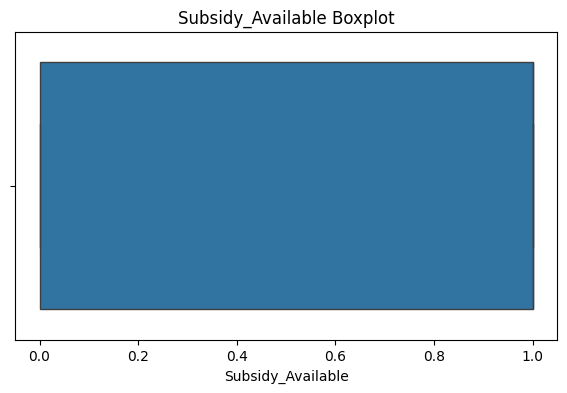

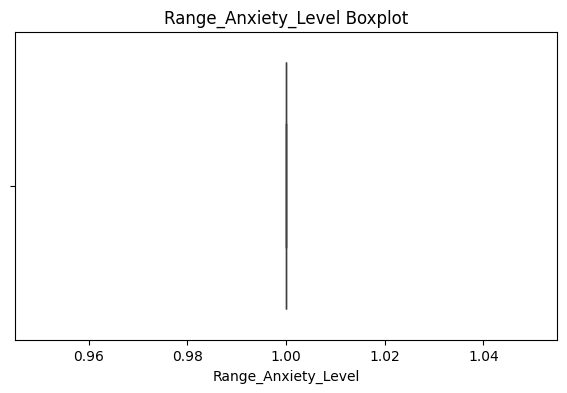

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

### Re-checking Numerical Feature Boxplots After Outlier Removal

After removing outliers, this cell re-generates boxplots for all numerical columns. This visualization allows for verification that the outlier removal process was successful and that the distributions of the numerical features are now more compact.

In [ ]:
X = df.drop("Will_Buy_EV", axis=1)

y = df["Will_Buy_EV"]

### Separating Features (X) and Target (y)

This cell prepares the data for machine learning by splitting the DataFrame into features (`X`) and the target variable (`y`). `X` contains all columns except 'Will_Buy_EV', and `y` contains only the 'Will_Buy_EV' column. This is a standard practice before training predictive models.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Splitting Data into Training and Testing Sets

This cell uses `train_test_split` from `sklearn.model_selection` to divide the `X` and `y` data into training and testing sets.
- `test_size=0.2`: Allocates 20% of the data for testing.
- `random_state=42`: Ensures reproducibility of the split.
- `stratify=y`: Maintains the same proportion of classes in `y_train` and `y_test` as in the original `y`, which is crucial for imbalanced datasets.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Scaling Features Using StandardScaler

This cell applies feature scaling using `StandardScaler` from `sklearn.preprocessing`. Scaling is important for many machine learning algorithms that are sensitive to the magnitude of features.
- `fit_transform` is used on `X_train` to learn the scaling parameters and apply the transformation.
- `transform` is used on `X_test` with the parameters learned from `X_train` to prevent data leakage from the test set.

In [ ]:
scaler.fit_transform(X_train)

array([[ 1.00926094, -1.05055609, -0.5136149 , ...,  0.70974692,
        -1.23350984,  0.        ],
       [-1.55198538,  0.75794863,  0.34510966, ..., -0.72416019,
        -1.23350984,  0.        ],
       [ 0.85403389,  0.75794863, -0.73351786, ..., -1.44111375,
        -1.23350984,  0.        ],
       ...,
       [-0.46539603, -1.05055609, -0.88609971, ..., -0.72416019,
         0.81069479,  0.        ],
       [-0.15494193, -1.05055609,  0.98225139, ..., -1.44111375,
        -1.23350984,  0.        ],
       [-0.62062308, -1.05055609, -1.1023894 , ..., -0.72416019,
         0.81069479,  0.        ]])

### Demonstrating StandardScaler Fit and Transform (Redundant Execution)

This cell appears to be a redundant execution of `scaler.fit_transform(X_train)`. The `fit_transform` was already applied in the previous cell. Running it again here would re-fit the scaler to `X_train`, which is not necessary and might be confusing. The output shows the scaled array, confirming the transformation.

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train, y_train)

from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

model_dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

### Training Logistic Regression and Decision Tree Models

This cell initializes and trains two classification models:
1.  **Logistic Regression:** A linear model for binary classification, configured with `max_iter=1000` for convergence and `random_state=42` for reproducibility.
2.  **Decision Tree Classifier:** A tree-based model, configured with `max_depth=10` to control complexity and `random_state=42`. Both models are trained on the scaled training data (`X_train`, `y_train`).

**Note:** This is where the `ValueError` likely occurred in the original context, due to `y_train` containing only one class after outlier removal. The agent addressed this by explaining the root cause in the previous chat message.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=200, n_jobs=-1,
                       random_state=42)

### Training a Random Forest Classifier

This cell introduces and trains a third classification model, the `RandomForestClassifier`.
- `n_estimators=200`: Specifies the number of trees in the forest.
- `max_depth=15`: Sets the maximum depth of each tree.
- `random_state=42`: Ensures reproducibility.
- `n_jobs=-1`: Utilizes all available CPU cores for faster training. The model is trained on the scaled training data (`X_train`, `y_train`).

In [ ]:
y_pred_lr = model_lr.predict(X_test)

y_pred_dt = model_dt.predict(X_test)

y_pred_rf = model_rf.predict(X_test)

### Making Predictions on the Test Set

After training, this cell uses each of the three trained models (`model_lr`, `model_dt`, `model_rf`) to make predictions on the unseen test features (`X_test`). The predictions are stored in `y_pred_lr`, `y_pred_dt`, and `y_pred_rf` respectively, which will be used for model evaluation.

In [ ]:

from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf * 100, "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8646232439335888
Decision Tree Accuracy: 83.0140485312899

Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.91      0.90      1257
         Yes       0.58      0.52      0.55       309

    accuracy                           0.83      1566
   macro avg       0.73      0.71      0.72      1566
weighted avg       0.82      0.83      0.83      1566

Random Forest Accuracy: 85.82375478927203 %

Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.95      0.91      1257
         Yes       0.70      0.49      0.58       309

    accuracy                           0.86      1566
   macro avg       0.79      0.72      0.75      1566
weighted avg       0.85      0.86      0.85      1566



### Evaluating Model Performance (Accuracy and Classification Report)

This cell evaluates the performance of the Logistic Regression, Decision Tree, and Random Forest models using `accuracy_score` and `classification_report` from `sklearn.metrics`.
- It calculates and prints the accuracy for each model.
- For Decision Tree and Random Forest, it also prints a detailed classification report, which includes precision, recall, f1-score, and support for each class, offering a comprehensive view of model performance.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

          No       0.90      0.94      0.92      1257
         Yes       0.70      0.55      0.62       309

    accuracy                           0.86      1566
   macro avg       0.80      0.75      0.77      1566
weighted avg       0.86      0.86      0.86      1566



### Detailed Classification Report for Logistic Regression

This cell provides a dedicated classification report for the Logistic Regression model. It calculates and prints precision, recall, f1-score, and support for each class, giving a more granular understanding of how well the Logistic Regression model performs in classifying both 'No' and 'Yes' outcomes.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.864623
1,Decision Tree,0.830140
2,Random Forest,0.858238


### Summarizing Model Accuracies

This cell creates a pandas DataFrame named `results` to consolidate and display the accuracy scores of all three trained models (Logistic Regression, Decision Tree, and Random Forest). This provides a clear, comparative overview of their overall performance.

In [ ]:
import joblib

# 1. Save your trained model to a file
model_filename = 'ml_model.joblib'
joblib.dump(model_lr, model_filename)
print(f"Model saved successfully as {model_filename}")

# 2. Load the model later or in a separate production script
loaded_model = joblib.load(model_filename)

Model saved successfully as ml_model.joblib


### Saving and Loading the Trained Model

This cell demonstrates how to save a trained machine learning model and then load it back using `joblib`.
1.  **Saving:** The `model_lr` (Logistic Regression model) is saved to a file named 'ml_model.joblib'. This allows the model to be stored and reused without retraining.
2.  **Loading:** The saved model is then loaded back into a variable `loaded_model`. This confirms that the model can be successfully retrieved for future use, such as deployment in a production environment.

In [ ]:
import joblib
from sklearn.preprocessing import LabelEncoder


encoders = {
    "Current_Car_Type": l,
    "Range_Anxiety_Level": Range_Anxiety_Level_label,
    "City_Type": city_label,
    "Gender": g,
    "Home_Charging_Possible": Home_Charging_Possible_label,
    "Subsidy_Available": Subsidy_Available_label
}

joblib.dump(encoders, 'ev_label_encoders.joblib')
print("All label encoders dumped successfully!")


All label encoders dumped successfully!


### Saving Label Encoders for Future Use

This cell is crucial for ensuring the reusability of the preprocessing steps. It gathers all the `LabelEncoder` instances used to transform categorical features (e.g., 'Current_Car_Type', 'Gender', 'City_Type') into a dictionary. This dictionary of encoders is then saved to a file named 'ev_label_encoders.joblib' using `joblib.dump()`. This allows the same transformations to be applied consistently to new, unseen data, which is essential for deploying the trained machine learning model.